In [1]:
import os
import sqlite3

import pandas as pd
from pycaret.classification import *

from features import label_encoder
from utilities import get_path, read_data_from_database

In [2]:
pd.options.display.max_columns = None  # Remove "dots" from display when printing dataframes

In [3]:
PATH = get_path(1)
DATABASE_FOLDER = PATH + 'data/preprocessing/BANCO_BOGOTA.db'

In [4]:
df_train = read_data_from_database(DATABASE_FOLDER, 'prep_train_data')
df_test = read_data_from_database(DATABASE_FOLDER, 'prep_test_data')

In [5]:
df_train.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,Dia,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
1,2,37,servicios,casado,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
2,3,40,administrador negocio,casado,primaria,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
3,4,56,servicios,casado,bachillerato,0.0,0.0,1.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
4,7,25,servicios,soltero,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0


# Label encoder

In [6]:
labels_to_encoders_name = {
    'Tipo_Trabajo':'Tipo_Trabajo_ENC',
    'Estado_Civil':'Estado_Civil_ENC',
    'Educacion':'Educacion_ENC',    
    'Contacto':'Contacto_ENC',
    'Mes':'Mes_ENC',
    'Dia':'Dia_ENC',
    'Resultado_Anterior':'Resultado_Anterior_ENC'
    }

for var_encoder, encoder_name in labels_to_encoders_name.items():
    label_encoder(var_encoder, encoder_name, df_train)
    label_encoder(var_encoder, encoder_name, df_test)

In [7]:
df_train[[
    'Tipo_Trabajo', 'Tipo_Trabajo_ENC', 'Estado_Civil', 'Estado_Civil_ENC',
    'Educacion', 'Educacion_ENC', 'Contacto', 'Contacto_ENC', 'Mes', 'Mes_ENC',
    'Dia', 'Dia_ENC','Resultado_Anterior', 'Resultado_Anterior_ENC'
    ]].sample(n=10).head(10)

,Tipo_Trabajo,Tipo_Trabajo_ENC,Estado_Civil,Estado_Civil_ENC,Educacion,Educacion_ENC,Contacto,Contacto_ENC,Mes,Mes_ENC,Dia,Dia_ENC,Resultado_Anterior,Resultado_Anterior_ENC
18444,empleado,3,casado,0,estudiante universitario,2,celular,0,may,6,lun,1,sin contacto,2
150,tecnico,8,divorciado,1,estudiante universitario,2,telefono fijo,1,may,6,lun,1,sin contacto,2
10546,administrador negocio,0,soltero,2,bachillerato incompleto,1,celular,0,jul,3,jue,0,sin contacto,2
10422,administrador negocio,0,soltero,2,bachillerato,0,celular,0,jul,3,jue,0,sin contacto,2
22646,administrador negocio,0,soltero,2,pregrado,5,celular,0,ago,1,jue,0,sin contacto,2
18499,tecnico,8,casado,0,bachillerato,0,celular,0,may,6,lun,1,sin contacto,2
9515,empleado,3,casado,0,primaria,6,celular,0,jul,3,jue,0,sin contacto,2
11522,tecnico,8,soltero,2,bachillerato,0,celular,0,ago,1,mar,2,sin contacto,2
5594,administrador negocio,0,casado,0,estudiante universitario,2,telefono fijo,1,jun,4,mié,3,sin contacto,2
5713,estudiante,5,soltero,2,bachillerato incompleto,1,telefono fijo,1,jun,4,jue,0,sin contacto,2


# Auto Machine Learning

In [8]:
df_new = df_train[[
    'Edad', 'Tipo_Trabajo_ENC', 'Estado_Civil_ENC', 'Educacion_ENC', 
    'mora', 'Vivienda', 'Consumo', 'Contacto_ENC', 'Mes_ENC', 'Dia_ENC', 
    'Campana', 'Dias_Ultima_Camp', 'No_Contactos', 'Resultado_Anterior_ENC',
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
    'y'
    ]].copy()

df_new.head()

,Edad,Tipo_Trabajo_ENC,Estado_Civil_ENC,Educacion_ENC,mora,Vivienda,Consumo,Contacto_ENC,Mes_ENC,Dia_ENC,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior_ENC,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,57,7,0,0,0.0,0.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
1,37,7,0,0,0.0,1.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
2,40,0,0,6,0.0,0.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
3,56,7,0,0,0.0,0.0,1.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
4,25,7,2,0,0.0,1.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0


In [9]:
data = df_new.sample(frac=0.8, random_state=0)
data_unseen = df_train.drop(data.index)

In [10]:
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print(f'Datos para modelar: {data.shape}; y datos para predecir: {data_unseen.shape}')

Datos para modelar: (18479, 20); y datos para predecir: (4620, 28)


In [11]:
model_setup = setup(data=data, target='y')

,Description,Value
0,Session id,3343
1,Target,y
2,Target type,Binary
3,Original data shape,"(18479, 20)"
4,Transformed data shape,"(18479, 30)"
5,Transformed train set shape,"(12935, 30)"
6,Transformed test set shape,"(5544, 30)"
7,Numeric features,17
8,Categorical features,2
9,Preprocess,True


In [12]:
models()  # Modelos suportados

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [13]:
best_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8995,0.7860,0.2405,0.6582,0.3512,0.3094,0.3565,0.1870
ada,Ada Boost Classifier,0.8993,0.7799,0.2295,0.6652,0.3404,0.2997,0.3505,0.0860
lightgbm,Light Gradient Boosting Machine,0.8979,0.7754,0.2684,0.6174,0.3735,0.3272,0.3614,0.1350
ridge,Ridge Classifier,0.8977,0.7782,0.2036,0.6593,0.3101,0.2714,0.3273,0.0210
catboost,CatBoost Classifier,0.8969,0.7766,0.2663,0.6091,0.3689,0.3221,0.3558,3.5470
xgboost,Extreme Gradient Boosting,0.8939,0.7511,0.2827,0.5705,0.3759,0.3253,0.3503,0.1310
rf,Random Forest Classifier,0.8934,0.7568,0.2772,0.5644,0.3707,0.3199,0.3447,0.1490
lr,Logistic Regression,0.8923,0.7657,0.1709,0.5927,0.2640,0.2247,0.2767,0.8570
et,Extra Trees Classifier,0.8882,0.7468,0.2970,0.5122,0.3754,0.3189,0.3334,0.1470
dummy,Dummy Classifier,0.8865,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0260


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

In [14]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8980,0.7474,0.2109,0.6596,0.3196,0.2800,0.3340
1,0.8964,0.7635,0.1973,0.6444,0.3021,0.2628,0.3175
2,0.8980,0.7713,0.2517,0.6271,0.3592,0.3146,0.3537
3,0.9049,0.8062,0.2925,0.6935,0.4115,0.3690,0.4100
4,0.8964,0.7727,0.2177,0.6275,0.3232,0.2812,0.3280
5,0.9018,0.7969,0.2329,0.6939,0.3487,0.3095,0.3643
6,0.8987,0.7808,0.1918,0.6829,0.2995,0.2630,0.3259
7,0.8894,0.7973,0.1905,0.5385,0.2814,0.2360,0.2739
8,0.8995,0.7675,0.2449,0.6545,0.3564,0.3140,0.3591


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=3343)


In [15]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8980,0.7474,0.2109,0.6596,0.3196,0.2800,0.3340
1,0.8964,0.7635,0.1973,0.6444,0.3021,0.2628,0.3175
2,0.8980,0.7713,0.2517,0.6271,0.3592,0.3146,0.3537
3,0.9049,0.8062,0.2925,0.6935,0.4115,0.3690,0.4100
4,0.8964,0.7727,0.2177,0.6275,0.3232,0.2812,0.3280
5,0.9018,0.7969,0.2329,0.6939,0.3487,0.3095,0.3643
6,0.8987,0.7808,0.1918,0.6829,0.2995,0.2630,0.3259
7,0.8894,0.7973,0.1905,0.5385,0.2814,0.2360,0.2739
8,0.8995,0.7675,0.2449,0.6545,0.3564,0.3140,0.3591


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=3343)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8972,0.7534,0.1565,0.7188,0.2570,0.2255,0.3037
1,0.9003,0.7408,0.1633,0.8000,0.2712,0.2420,0.3332
2,0.8957,0.7691,0.1701,0.6579,0.2703,0.2345,0.2983
3,0.9080,0.8034,0.2449,0.8182,0.3770,0.3426,0.4166
4,0.8964,0.7641,0.1565,0.6970,0.2556,0.2232,0.2974
5,0.8956,0.7853,0.1370,0.6897,0.2286,0.1986,0.2760
6,0.8995,0.7863,0.1575,0.7667,0.2614,0.2318,0.3184
7,0.8948,0.7647,0.1633,0.6486,0.2609,0.2255,0.2893
8,0.8995,0.7634,0.1837,0.7297,0.2935,0.2596,0.3331


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


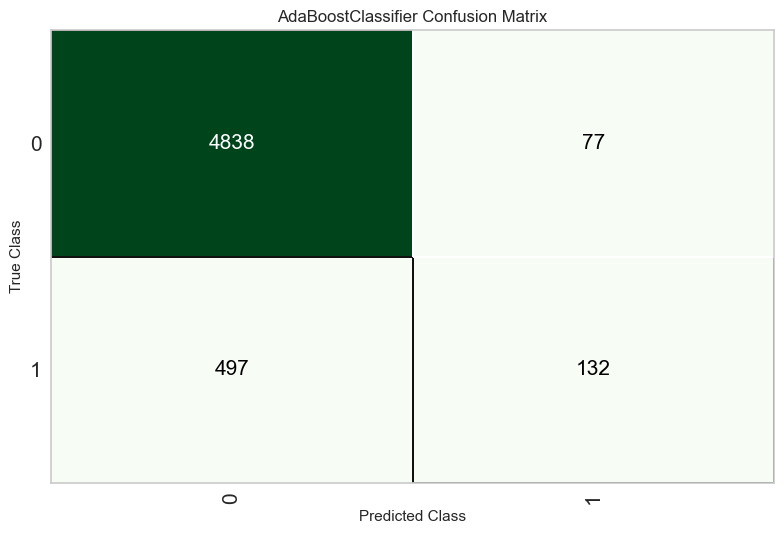

In [16]:
tuned_ada = tune_model(ada)
plot_model(tuned_ada, plot='confusion_matrix')

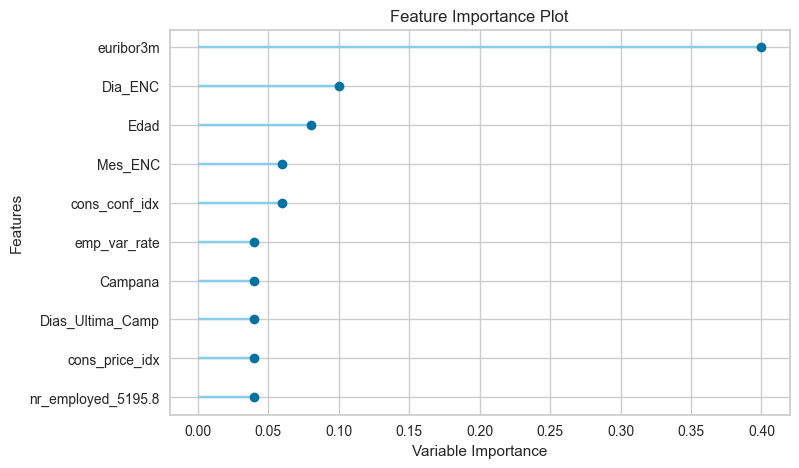

In [17]:
plot_model(tuned_ada, plot='feature')

In [18]:
unseen_predictions = predict_model(tuned_ada, data=data_unseen)
unseen_predictions[['y', 'prediction_label', 'prediction_score']].sample(n=25).head(25)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.9045,0.8038,0.2292,0.6494,0.3388,0.2998,0.3477


,y,prediction_label,prediction_score
4251,1,0,0.5051
1093,0,0,0.5158
104,0,0,0.5167
2659,0,0,0.5141
163,0,0,0.5168
3214,0,0,0.5070
2607,0,0,0.6866
674,0,0,0.5177
851,0,0,0.5162
2633,0,0,0.5129


In [19]:
final_ada = finalize_model(tuned_ada)
print(final_ada)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Edad', 'Tipo_Trabajo_ENC',
                                             'Estado_Civil_ENC',
                                             'Educacion_ENC', 'mora',
                                             'Vivienda', 'Consumo',
                                             'Contacto_ENC', 'Mes_ENC',
                                             'Dia_ENC', 'Dias_Ultima_Camp',
                                             'No_Contactos',
                                             'Resultado_Anterior_ENC',
                                             'emp_var_rate', 'cons_price_idx',
                                             'cons_conf_idx', 'euribor3m']...
                 TransformerWrapper(exclude=None, include=['Campana'],
                                    transformer=TargetEncoder(cols=['Campana'],
         

# Save model

In [20]:
save_model(final_ada, PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Edad', 'Tipo_Trabajo_ENC',
                                              'Estado_Civil_ENC',
                                              'Educacion_ENC', 'mora',
                                              'Vivienda', 'Consumo',
                                              'Contacto_ENC', 'Mes_ENC',
                                              'Dia_ENC', 'Dias_Ultima_Camp',
                                              'No_Contactos',
                                              'Resultado_Anterior_ENC',
                                              'emp_var_rate', 'cons_price_idx',
                                              'cons_conf_idx', 'euribor3m']...
                  TransformerWrapper(exclude=None, include=['Campana'],
                                     transformer=TargetEncoder(cols=['Campa

# Deploy

In [21]:
ada_model = load_model(PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Loaded


In [22]:
df_implement = predict_model(ada_model, data=df_test)
df_implement = df_implement.rename({
    'prediction_label':'y'
    }, axis=1)

In [23]:
df_implement.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,...,nr_employed,Tipo_Trabajo_ENC,Estado_Civil_ENC,Educacion_ENC,Contacto_ENC,Mes_ENC,Dia_ENC,Resultado_Anterior_ENC,y,prediction_score
0,5,41,empleado,casado,pregrado,0.0,0.0,0.0,telefono fijo,may,...,5191,3,0,5,1,6,1,2,0,0.5176
1,6,24,tecnico,soltero,estudiante universitario,0.0,1.0,0.0,telefono fijo,may,...,5191,8,2,2,1,6,1,2,0,0.5175
2,11,57,ama de casa,divorciado,preescolar,0.0,1.0,0.0,telefono fijo,may,...,5191,1,1,4,1,6,1,2,0,0.5177
3,13,54,pensionado,casado,bachillerato incompleto,0.0,1.0,1.0,telefono fijo,may,...,5191,6,0,1,1,6,1,2,0,0.5177
4,16,39,vive de los arriendos,soltero,bachillerato incompleto,0.0,0.0,0.0,telefono fijo,may,...,5191,10,2,1,1,6,1,2,0,0.5183


# Save data

In [24]:
# Load to DataBase
try:
    # Create a connection to the SQLite database
    conn = sqlite3.connect(os.path.join(PATH, 'data', 'preprocessing', 'BANCO_BOGOTA.db'))

    df_implement.to_sql(
    'Result_TechnicalTest_DS_AMT', conn, index=False, if_exists='replace'    
    )
    # Commit changes
    conn.commit()
    print('Data loaded successfully to the database.')
except Exception as e:
    print(f'An error occurred while loading data to the database: {str(e)}')
    if conn is not None:
        conn.rollback()
finally:
    # Close connection
    if conn is not None:
        conn.close()
        print('Database connection closed.')

Data loaded successfully to the database.
Database connection closed.


In [25]:
del df_train, df_test, df_new, df_implement  # Delete variables to free memory